# 3 — Proposed: Hybrid CNN-BiGRU-Attention (Multimodal)
**Author:** Revanth Katari

Architecture:
```
Text (768)  ─┐
Image (1280) ─┤  Project to 512  →  Stack as sequence (B, 4, 512)
Audio (768)  ─┤  →  CNN  →  BiGRU  →  Sequential Attention  →  Classify
Video (768)  ─┘
```

This model treats the four modality projections as a **4-step sequence**,
allowing CNN to extract cross-modal local patterns and BiGRU to capture
sequential dependencies between modalities.

In [1]:
import sys, os, json
sys.path.insert(0, os.path.join(os.pardir, "src"))

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from config import (
    EMBEDDINGS_DIR, MODELS_DIR, RESULTS_DIR,
    TEXT_DIM, IMAGE_DIM, AUDIO_DIM, VIDEO_DIM, HIDDEN_DIM,
    NUM_CLASSES, DROPOUT, NUM_FILTERS, BATCH_SIZE,
    LEARNING_RATE, WEIGHT_DECAY, NUM_EPOCHS, PATIENCE, RANDOM_SEED,
)
from data_utils import load_embeddings, create_splits, make_dataloader
from models import HybridCNNBiGRUMultimodal
from train_utils import train_one_epoch, evaluate

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

Device: cpu


/home/katarir/Downloads/FINAL/venv/lib/python3.13/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [2]:
text, image, audio, video, labels = load_embeddings(EMBEDDINGS_DIR)
train_split, val_split, test_split = create_splits(
    text, image, audio, video, labels, seed=RANDOM_SEED
)
train_loader = make_dataloader(train_split, BATCH_SIZE, shuffle=True)
val_loader   = make_dataloader(val_split, BATCH_SIZE, shuffle=False)
test_loader  = make_dataloader(test_split, BATCH_SIZE, shuffle=False)
print(f"Train: {len(train_split[-1]):,}  Val: {len(val_split[-1]):,}  Test: {len(test_split[-1]):,}")

[data] Loaded 43,131 samples
       text=(43131, 768) image=(43131, 1280) audio=(43131, 768) video=(43131, 768)
Train: 30,191  Val: 4,313  Test: 8,627


## 3.1 Model

In [3]:
model = HybridCNNBiGRUMultimodal(
    text_dim=TEXT_DIM, image_dim=IMAGE_DIM,
    audio_dim=AUDIO_DIM, video_dim=VIDEO_DIM,
    hidden=HIDDEN_DIM, num_filters=NUM_FILTERS,
    num_classes=NUM_CLASSES, dropout=DROPOUT,
    use_cnn=True, use_attention=True,
).to(device)

print(f"Total params:     {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(model)

Total params:     4,008,898
Trainable params: 4,008,898
HybridCNNBiGRUMultimodal(
  (text_proj): Linear(in_features=768, out_features=512, bias=True)
  (image_proj): Linear(in_features=1280, out_features=512, bias=True)
  (audio_proj): Linear(in_features=768, out_features=512, bias=True)
  (video_proj): Linear(in_features=768, out_features=512, bias=True)
  (proj_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (conv): Sequential(
    (0): Conv1d(512, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (gru): GRU(64, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): SequentialAttention(
    (W): Linear(in_features=512, out_features=512, bias=True)
    (v): Linear(in_features=512, out_features=1, bias=False)
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (head): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=T

## 3.2 Training

In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_f1": [], "val_auc": []}
best_f1, wait = 0.0, 0
save_path = os.path.join(MODELS_DIR, "hybrid_cnn_bigru_attn.pt")

for epoch in range(1, NUM_EPOCHS + 1):
    tl, ta = train_one_epoch(model, train_loader, optimizer, criterion, device)
    vl, vm, _, _, _ = evaluate(model, val_loader, criterion, device)
    scheduler.step(vl)

    history["train_loss"].append(tl)
    history["val_loss"].append(vl)
    history["train_acc"].append(ta)
    history["val_acc"].append(vm["accuracy"])
    history["val_f1"].append(vm["f1"])
    history["val_auc"].append(vm["auc"])

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS}  "
          f"TrL={tl:.4f} TrA={ta:.4f}  "
          f"VL={vl:.4f} VA={vm['accuracy']:.4f} "
          f"VF1={vm['f1']:.4f} VAUC={vm['auc']:.4f}")

    if vm["f1"] > best_f1:
        best_f1 = vm["f1"]
        torch.save(model.state_dict(), save_path)
        print(f"  -> Saved (F1={best_f1:.4f})")
        wait = 0
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

Epoch 01/15  TrL=0.3013 TrA=0.8718  VL=0.2426 VA=0.9045 VF1=0.9045 VAUC=0.9502
  -> Saved (F1=0.9045)
Epoch 02/15  TrL=0.2316 TrA=0.9132  VL=0.2273 VA=0.9103 VF1=0.9093 VAUC=0.9548
  -> Saved (F1=0.9093)
Epoch 03/15  TrL=0.1949 TrA=0.9323  VL=0.2317 VA=0.9151 VF1=0.9148 VAUC=0.9565
  -> Saved (F1=0.9148)
Epoch 04/15  TrL=0.1592 TrA=0.9512  VL=0.2684 VA=0.9142 VF1=0.9145 VAUC=0.9574
Epoch 05/15  TrL=0.1304 TrA=0.9641  VL=0.3716 VA=0.9107 VF1=0.9106 VAUC=0.9425
Epoch 06/15  TrL=0.0962 TrA=0.9779  VL=0.3727 VA=0.9156 VF1=0.9154 VAUC=0.9120
  -> Saved (F1=0.9154)
Epoch 07/15  TrL=0.0794 TrA=0.9826  VL=0.5234 VA=0.9098 VF1=0.9098 VAUC=0.8950
Epoch 08/15  TrL=0.0738 TrA=0.9841  VL=0.5160 VA=0.9107 VF1=0.9107 VAUC=0.9121
Epoch 09/15  TrL=0.0671 TrA=0.9858  VL=0.5938 VA=0.9114 VF1=0.9111 VAUC=0.8846
Epoch 10/15  TrL=0.0615 TrA=0.9874  VL=0.6486 VA=0.9103 VF1=0.9106 VAUC=0.8983
Epoch 11/15  TrL=0.0615 TrA=0.9871  VL=0.6590 VA=0.9112 VF1=0.9112 VAUC=0.8902
Early stopping at epoch 11


## 3.3 Training curves

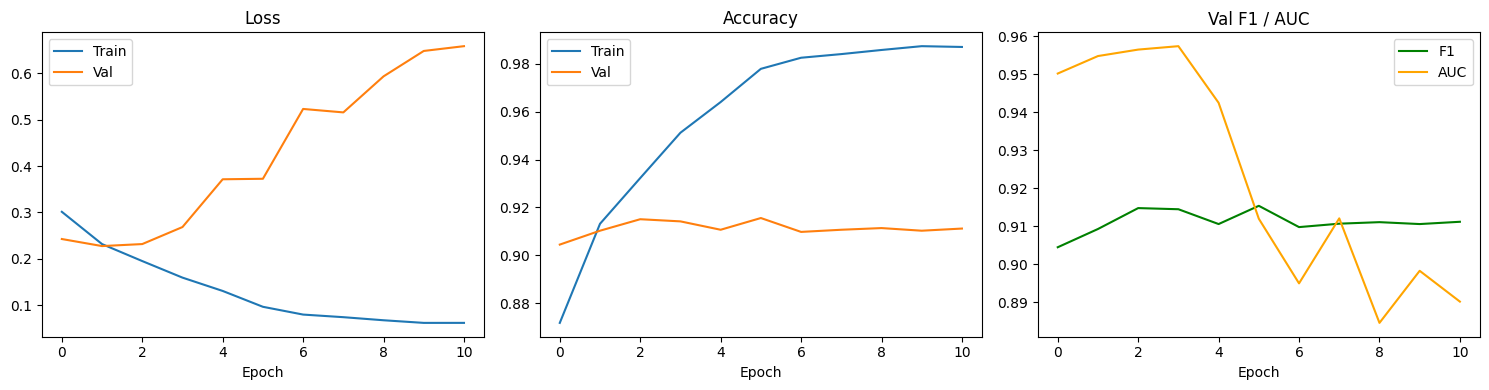

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"], label="Val")
axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(history["train_acc"], label="Train")
axes[1].plot(history["val_acc"], label="Val")
axes[1].set_title("Accuracy"); axes[1].legend()
axes[2].plot(history["val_f1"], label="F1", color="green")
axes[2].plot(history["val_auc"], label="AUC", color="orange")
axes[2].set_title("Val F1 / AUC"); axes[2].legend()
for ax in axes: ax.set_xlabel("Epoch")
plt.tight_layout()
plt.show()

## 3.4 Test evaluation

In [6]:
model.load_state_dict(torch.load(save_path, map_location=device, weights_only=True))
_, test_metrics, preds, probs, true_labels = evaluate(model, test_loader, criterion, device)

print("Test Metrics:")
for k, v in test_metrics.items():
    print(f"  {k:>10s}: {v:.4f}")

with open(os.path.join(RESULTS_DIR, "hybrid_cnn_bigru_attn_metrics.json"), "w") as f:
    json.dump({"test": test_metrics, "history": history}, f, indent=2)
print("Results saved.")

Test Metrics:
    accuracy: 0.9184
   precision: 0.9179
      recall: 0.9184
          f1: 0.9181
         auc: 0.9142
Results saved.


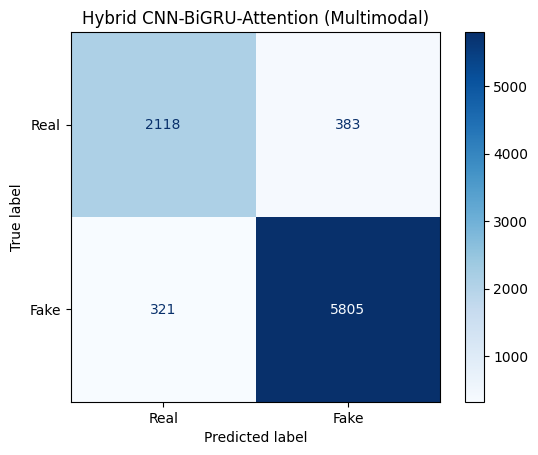

              precision    recall  f1-score   support

        Real       0.87      0.85      0.86      2501
        Fake       0.94      0.95      0.94      6126

    accuracy                           0.92      8627
   macro avg       0.90      0.90      0.90      8627
weighted avg       0.92      0.92      0.92      8627



In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

cm = confusion_matrix(true_labels, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Real", "Fake"])
disp.plot(cmap="Blues")
plt.title("Hybrid CNN-BiGRU-Attention (Multimodal)")
plt.show()

print(classification_report(true_labels, preds, target_names=["Real", "Fake"]))